In [1]:
import pandas as pd

# Load dataset
df_price = pd.read_csv("Price_Agriculture_commodities_Week.csv")

# Preview
print(df_price.head())

# Columns
print("Columns:", df_price.columns)

# Info
print(df_price.info())

# Null values
print(df_price.isnull().sum())

     State District    Market              Commodity      Variety Grade  \
0  Gujarat   Amreli  Damnagar  Bhindi(Ladies Finger)       Bhindi   FAQ   
1  Gujarat   Amreli  Damnagar                Brinjal        Other   FAQ   
2  Gujarat   Amreli  Damnagar                Cabbage      Cabbage   FAQ   
3  Gujarat   Amreli  Damnagar            Cauliflower  Cauliflower   FAQ   
4  Gujarat   Amreli  Damnagar      Coriander(Leaves)    Coriander   FAQ   

  Arrival_Date  Min Price  Max Price  Modal Price  
0   27-07-2023     4100.0     4500.0       4350.0  
1   27-07-2023     2200.0     3000.0       2450.0  
2   27-07-2023     2350.0     3000.0       2700.0  
3   27-07-2023     7000.0     7500.0       7250.0  
4   27-07-2023     8400.0     9000.0       8850.0  
Columns: Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min Price', 'Max Price', 'Modal Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23093 entries, 0 to 

In [2]:
df_p = df_price.copy()

# Drop leakage columns
df_p = df_p.drop(['Min Price', 'Max Price'], axis=1)

# Convert date
df_p['Arrival_Date'] = pd.to_datetime(df_p['Arrival_Date'], dayfirst=True)

# Extract useful features
df_p['Year'] = df_p['Arrival_Date'].dt.year
df_p['Month'] = df_p['Arrival_Date'].dt.month

# Drop original date
df_p = df_p.drop('Arrival_Date', axis=1)

print(df_p.head())
print("Columns:", df_p.columns)

     State District    Market              Commodity      Variety Grade  \
0  Gujarat   Amreli  Damnagar  Bhindi(Ladies Finger)       Bhindi   FAQ   
1  Gujarat   Amreli  Damnagar                Brinjal        Other   FAQ   
2  Gujarat   Amreli  Damnagar                Cabbage      Cabbage   FAQ   
3  Gujarat   Amreli  Damnagar            Cauliflower  Cauliflower   FAQ   
4  Gujarat   Amreli  Damnagar      Coriander(Leaves)    Coriander   FAQ   

   Modal Price  Year  Month  
0       4350.0  2023      7  
1       2450.0  2023      7  
2       2700.0  2023      7  
3       7250.0  2023      7  
4       8850.0  2023      7  
Columns: Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Modal Price', 'Year', 'Month'],
      dtype='object')


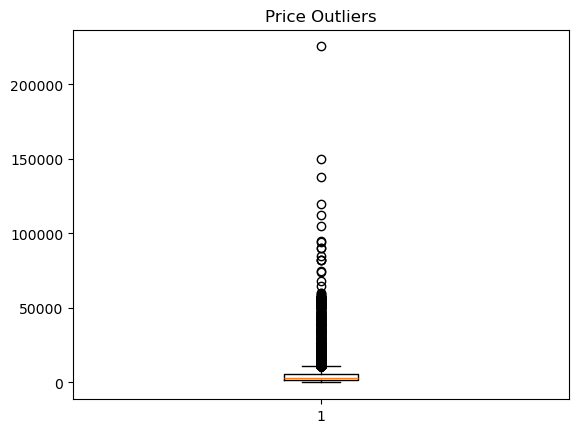

count     23093.000000
mean       4602.917742
std        5843.822711
min           0.830000
25%        1955.000000
50%        3000.000000
75%        5500.000000
max      225500.000000
Name: Modal Price, dtype: float64


In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_p['Modal Price'])
plt.title("Price Outliers")
plt.show()

print(df_p['Modal Price'].describe())

In [4]:
# Remove top 1% extreme values
upper_limit = df_p['Modal Price'].quantile(0.99)

df_p = df_p[df_p['Modal Price'] <= upper_limit]

print("After removing outliers:", df_p.shape)

After removing outliers: (22862, 9)


In [5]:
from sklearn.preprocessing import LabelEncoder
import joblib

df_p_processed = df_p.copy()

categorical_cols = df_p_processed.select_dtypes(include=['object']).columns

encoders_price = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_p_processed[col] = le.fit_transform(df_p_processed[col])
    encoders_price[col] = le

joblib.dump(encoders_price, "price_encoders.pkl")

X_price = df_p_processed.drop("Modal Price", axis=1)
y_price = df_p_processed["Modal Price"]

joblib.dump(X_price.columns.tolist(), "price_features.pkl")

print("Encoding Done ✅")
print("X shape:", X_price.shape)
print("y shape:", y_price.shape)

Encoding Done ✅
X shape: (22862, 8)
y shape: (22862,)


In [9]:
from sklearn.model_selection import train_test_split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

print("X_train:", X_train_p.shape)
print("X_test :", X_test_p.shape)
print("y_train:", y_train_p.shape)
print("y_test :", y_test_p.shape)

X_train: (18289, 8)
X_test : (4573, 8)
y_train: (18289,)
y_test : (4573,)


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")

    model.fit(X_train_p, y_train_p)
    y_pred = model.predict(X_test_p)

    mae = mean_absolute_error(y_test_p, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_p, y_pred))
    r2 = r2_score(y_test_p, y_pred)

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")


MODEL: Linear Regression
MAE : 2438.2151
RMSE: 3361.4063
R2  : 0.0132

MODEL: Random Forest
MAE : 627.1539
RMSE: 1341.3618
R2  : 0.8429

MODEL: Gradient Boosting
MAE : 1408.9585
RMSE: 2208.2226
R2  : 0.5741


In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train_p, y_train_p)
y_pred_p = model.predict(X_test_p)

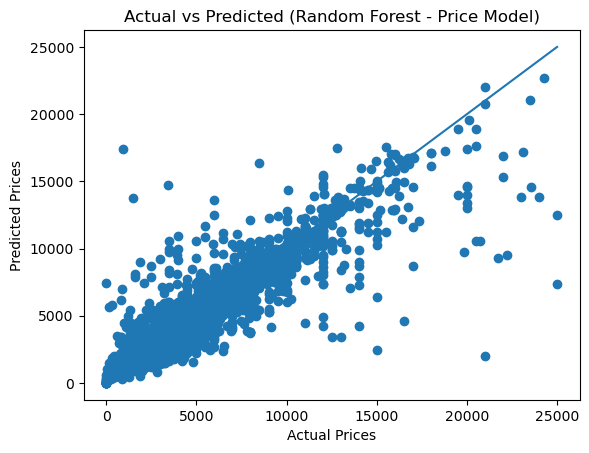

In [17]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Train model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_p, y_train_p)

# Predict
y_pred_p = rf_model.predict(X_test_p)

# Plot
plt.figure()
plt.scatter(y_test_p, y_pred_p)

# Ideal line (perfect prediction)
plt.plot([y_test_p.min(), y_test_p.max()],
         [y_test_p.min(), y_test_p.max()])

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Random Forest - Price Model)")
plt.show()

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf_price = RandomForestRegressor(n_estimators=100, random_state=42)

cv_scores = cross_val_score(
    rf_price,
    X_price,
    y_price,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Average R2:", cv_scores.mean())

CV Scores: [0.87694818 0.88660084 0.8747236  0.75370131 0.79738006]
Average R2: 0.8378707992624836


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_p, y_train_p)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.7925507637648067


In [10]:
import joblib
from sklearn.ensemble import RandomForestRegressor

# Final model
final_price_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# Train on full data
final_price_model.fit(X_price, y_price)

# Save model
joblib.dump(final_price_model, "price_model.pkl")

print("Price model saved ✅")

Price model saved ✅


In [14]:
def predict_price_final(crop, state, district):

    input_data = {
        'State': state,
        'District': district,
        'Market': 'Default',   # auto
        'Commodity': crop,
        'Variety': 'Other',    # auto
        'Grade': 'FAQ',        # auto
        'Year': 2023,          # auto
        'Month': 7             # auto
    }

    df_input = pd.DataFrame([input_data])

    # Encode safely
    for col in price_encoders:
        if col in df_input:
            if df_input[col][0] in price_encoders[col].classes_:
                df_input[col] = price_encoders[col].transform(df_input[col])
            else:
                df_input[col] = 0

    df_input = df_input.reindex(columns=price_features)

    predicted_price = price_model.predict(df_input)[0]

    return predicted_price